# MFCC (Mel-Frequency Cepstral Coefficients)

MFCC is one of the most widely used audio features in speech recognition, music genre classification, speaker identification, and audio ML tasks.


Steps:

Convert audio → Short-time frames

Apply Fourier Transform → Spectrogram

Apply Mel Filter Banks

Take Log

Apply DCT (Discrete Cosine Transform)

Result → MFCC features

In [20]:
import librosa
import numpy as np

# Load audio
y, sr = librosa.load("/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00000/bass.wav", sr=22050)

# Extract MFCC
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=40  # Common choice: 13 for speech, 40 for music
)

print(mfcc.shape)  # (40, time_frames)

(40, 1293)


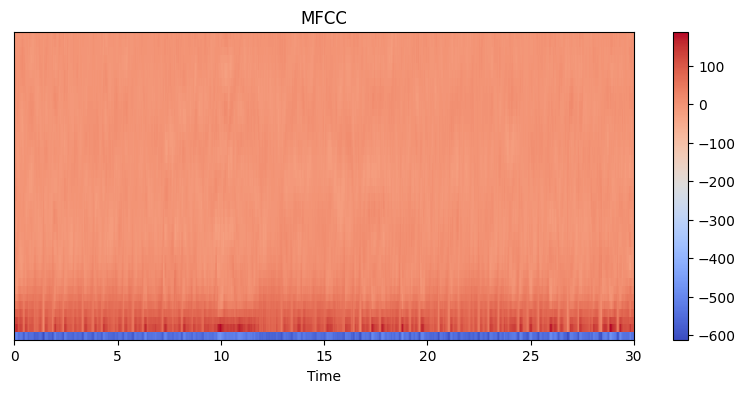

In [21]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

In [22]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torchaudio
import lightgbm as lgb

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

In [23]:
ROOT_DIR = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

SR = 22050
DURATION = 30
N_MFCC = 40
SAMPLES_PER_GENRE = 2000
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [24]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SR,
    n_mfcc=N_MFCC,
    melkwargs={
        "n_fft": 2048,
        "hop_length": 512,
        "n_mels": 128
    }
).to(device)

In [ ]:
def load_audio(path):
    waveform, sr = torchaudio.load(path)

    # Resample if needed
    if sr != SR:
        resampler = torchaudio.transforms.Resample(sr, SR)
        waveform = resampler(waveform)

    # Convert to mono
    waveform = waveform.mean(dim=0, keepdim=True)


    # Pad or trim to fixed duration
    max_len = SR * DURATION
    if waveform.shape[1] < max_len:
        pad = max_len - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, pad))

    return waveform[:, :max_len]

In [ ]:
genres = sorted(os.listdir(ROOT_DIR))

X_all = []
y_all = []

for genre in genres:

    print(f"\nProcessing genre: {genre}")

    genre_path = os.path.join(ROOT_DIR, genre)
    songs = os.listdir(genre_path)

    stems_memory = []


    # Preload stems into RAM
    print("Preloading stems...")
    for song in tqdm(songs):
        song_path = os.path.join(genre_path, song)

        stems = {}
        for stem_name in ["drums", "bass", "vocals", "other"]:
            path = os.path.join(song_path, f"{stem_name}.wav")
            stems[stem_name] = load_audio(path)

        stems_memory.append(stems)

    print("Stems loaded in RAM ")

    # Generate random mashups
    generated = 0

    while generated < SAMPLES_PER_GENRE:

        batch_waveforms = []

        for _ in range(min(BATCH_SIZE, SAMPLES_PER_GENRE - generated)):

            drums = random.choice(stems_memory)["drums"]
            bass = random.choice(stems_memory)["bass"]
            vocals = random.choice(stems_memory)["vocals"]
            others = random.choice(stems_memory)["other"]

            mashup = (
                drums * random.uniform(0.7, 1.3) +
                bass * random.uniform(0.7, 1.3) +
                vocals * random.uniform(0.7, 1.3) +
                others * random.uniform(0.7, 1.3)
            )

            # Add small random noise
            mashup += torch.randn_like(mashup) * 0.003

            batch_waveforms.append(mashup)

        batch_waveforms = torch.stack(batch_waveforms).to(device)

        # Extract MFCC features
        with torch.no_grad():
            mfcc = mfcc_transform(batch_waveforms)

            mfcc_mean = mfcc.mean(dim=3)
            mfcc_std = mfcc.std(dim=3)
            mfcc_max = mfcc.max(dim=3)[0]

            features = torch.cat([mfcc_mean, mfcc_std, mfcc_max], dim=2)

        features = features.cpu().numpy().reshape(features.shape[0], -1)

        X_all.append(features)
        y_all.extend([genre] * features.shape[0])

        generated += features.shape[0]

    # Free memory
    del stems_memory
    torch.cuda.empty_cache()


Processing genre: blues
Preloading stems...


100%|██████████| 100/100 [00:18<00:00,  5.40it/s]


Stems loaded in RAM 

Processing genre: classical
Preloading stems...


100%|██████████| 100/100 [00:18<00:00,  5.39it/s]


Stems loaded in RAM 

Processing genre: country
Preloading stems...


...

Stems loaded in RAM 

Processing genre: reggae
Preloading stems...


100%|██████████| 100/100 [00:31<00:00,  3.14it/s]


Stems loaded in RAM 

Processing genre: rock
Preloading stems...


100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


Stems loaded in RAM 


In [28]:
X = np.vstack(X_all)
y = np.array(y_all)

df = pd.DataFrame(X)
df["genre"] = y

print("\nFinal dataset shape:", df.shape)
df.head()


Final dataset shape: (20000, 121)


,0,1,2,3,4,5,6,7,8,9,...,111,112,113,114,115,116,117,118,119,genre
0,93.695312,49.898708,-23.565807,19.988661,-28.207979,-19.051069,-8.373143,-10.805871,-6.154047,-0.352928,...,21.583622,28.474426,27.832249,22.893278,24.749063,23.447575,17.285116,21.621723,21.491650,blues
1,92.688034,62.622009,-10.847074,37.248199,7.960226,8.808794,-7.190142,7.246675,-13.718373,-3.172839,...,20.197721,26.115183,18.877331,23.538294,24.878443,23.239588,16.937937,12.171651,25.596643,blues
2,-33.927200,80.054298,50.247383,25.502642,11.697324,-3.762992,-2.865013,-3.995870,-8.196961,-2.168113,...,18.352602,22.455921,12.080001,16.272388,16.302551,13.541045,18.691751,17.130739,20.794962,blues
3,69.887627,62.916683,-31.344463,-16.257803,-8.804126,-4.358856,-26.805285,-8.372094,-14.574765,-7.500711,...,23.378170,25.051901,20.336540,17.627110,22.633839,31.515476,28.505457,30.488485,18.803001,blues
4,96.180534,37.792431,-24.451963,20.431625,-2.434004,8.122987,-19.287001,3.647788,-6.326270,4.878985,...,25.886936,31.627392,32.897598,28.922592,34.629704,30.231348,19.641001,29.752432,23.422497,blues


In [29]:
df

,0,1,2,3,4,5,6,7,8,9,...,111,112,113,114,115,116,117,118,119,genre
0,93.695312,49.898708,-23.565807,19.988661,-28.207979,-19.051069,-8.373143,-10.805871,-6.154047,-0.352928,...,21.583622,28.474426,27.832249,22.893278,24.749063,23.447575,17.285116,21.621723,21.491650,blues
1,92.688034,62.622009,-10.847074,37.248199,7.960226,8.808794,-7.190142,7.246675,-13.718373,-3.172839,...,20.197721,26.115183,18.877331,23.538294,24.878443,23.239588,16.937937,12.171651,25.596643,blues
2,-33.927200,80.054298,50.247383,25.502642,11.697324,-3.762992,-2.865013,-3.995870,-8.196961,-2.168113,...,18.352602,22.455921,12.080001,16.272388,16.302551,13.541045,18.691751,17.130739,20.794962,blues
3,69.887627,62.916683,-31.344463,-16.257803,-8.804126,-4.358856,-26.805285,-8.372094,-14.574765,-7.500711,...,23.378170,25.051901,20.336540,17.627110,22.633839,31.515476,28.505457,30.488485,18.803001,blues
4,96.180534,37.792431,-24.451963,20.431625,-2.434004,8.122987,-19.287001,3.647788,-6.326270,4.878985,...,25.886936,31.627392,32.897598,28.922592,34.629704,30.231348,19.641001,29.752432,23.422497,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,41.949635,73.304840,16.789610,32.124245,23.176077,10.464793,-8.038834,9.475950,-6.245410,3.073079,...,29.680914,23.197739,19.695238,17.626694,21.614208,19.550650,18.567713,22.208061,19.677765,rock
19996,104.681801,63.433720,-22.863895,9.857288,-7.230145,-9.904401,-17.568995,-2.766423,-13.418104,-10.038286,...,22.560114,18.659575,20.380022,30.879025,22.503565,28.899651,28.221771,20.297262,25.934093,rock
19997,111.397491,37.546795,-29.404676,7.797684,10.283528,-1.261958,-5.696167,12.012223,-10.880939,2.370281,...,29.414938,22.601337,14.564142,23.692888,21.967937,17.225445,20.842726,25.554832,23.451199,rock
19998,64.358498,53.139355,14.780521,40.051060,-13.954741,16.452124,-18.076967,-9.156612,-11.195196,-8.770491,...,23.886292,21.634758,18.946653,18.808739,26.663450,16.777205,14.776375,16.785547,15.639447,rock


In [30]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Total classes:", len(le.classes_))

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Total classes: 10


In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.1,
    stratify=y_encoded,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (18000, 120)
Validation shape: (2000, 120)


In [33]:
lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

In [34]:
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30600
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 120
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, n_estimators=2000,
               n_jobs=-1, num_class=10, num_leaves=64, objective='multiclass',
               random_state=42, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8)

In [35]:
y_pred = lgb_model.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average="macro")

print("\n Macro F1 Score:", macro_f1)
print()
print(classification_report(y_val, y_pred, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Macro F1 Score: 0.8949974641856254

              precision    recall  f1-score   support

       blues       0.89      0.95      0.92       200
   classical       0.97      0.97      0.97       200
     country       0.86      0.85      0.86       200
       disco       0.83      0.81      0.82       200
      hiphop       0.89      0.88      0.88       200
        jazz       0.96      0.96      0.96       200
       metal       0.95      0.99      0.97       200
         pop       0.95      0.91      0.93       200
      reggae       0.82      0.84      0.83       200
        rock       0.83      0.79      0.81       200

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.89      2000
weighted avg       0.90      0.90      0.89      2000



In [36]:
import os
import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm

In [37]:
BASE_DIR = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup"
TEST_CSV = os.path.join(BASE_DIR, "test.csv")

SR = 22050
DURATION = 30
N_MFCC = 40

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [38]:
test_df = pd.read_csv(TEST_CSV)

print("Total test samples:", len(test_df))
test_df.head()

Total test samples: 3020


,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


In [39]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SR,
    n_mfcc=N_MFCC,
    melkwargs={
        "n_fft": 2048,
        "hop_length": 512,
        "n_mels": 128
    }
).to(device)

In [40]:
def extract_features(path):
    waveform, sr = torchaudio.load(path)

    # Resample if needed
    if sr != SR:
        resampler = torchaudio.transforms.Resample(sr, SR)
        waveform = resampler(waveform)

    # Convert to mono
    waveform = waveform.mean(dim=0, keepdim=True)

    # Pad or trim
    max_len = SR * DURATION
    if waveform.shape[1] < max_len:
        pad = max_len - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, pad))

    waveform = waveform[:, :max_len]
    waveform = waveform.unsqueeze(0).to(device)

    # Extract MFCC features
    with torch.no_grad():
        mfcc = mfcc_transform(waveform)

        mfcc_mean = mfcc.mean(dim=3)
        mfcc_std = mfcc.std(dim=3)
        mfcc_max = mfcc.max(dim=3)[0]

        features = torch.cat([mfcc_mean, mfcc_std, mfcc_max], dim=2)

    return features.cpu().numpy().flatten()

In [41]:
X_test = []

print("Extracting test features...")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    file_path = os.path.join(BASE_DIR, row["filename"])

    if not os.path.exists(file_path):
        print("Missing file:", file_path)
        continue

    features = extract_features(file_path)
    X_test.append(features)

X_test = np.array(X_test)

print("Test feature shape:", X_test.shape)

Extracting test features...


100%|██████████| 3020/3020 [00:51<00:00, 58.24it/s]

Test feature shape: (3020, 120)


In [42]:
test_preds_encoded = lgb_model.predict(X_test)

# Convert encoded labels back to original genre names
test_preds = le.inverse_transform(test_preds_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": test_preds
})

submission.to_csv("submission.csv", index=False)

print("Submission file created: submission.csv")
submission.head()

Submission file created: submission.csv


,id,genre
0,1,pop
1,2,blues
2,3,hiphop
3,4,hiphop
4,5,blues
